Hola **Julio**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma:

<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 


# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [67]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# cargar archivos

orders = pd.read_csv(
    'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')

catalog = pd.read_csv(
    'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')

marketing = pd.read_csv(
    'https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [31]:
# explorar datasets
display(orders.head())
orders.info()

display(catalog.head())
catalog.info()

display(marketing.head())
marketing.info()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [32]:
# tu código aquí
# revisar valores ausentes y duplicados

datasets = {
    'orders': orders,
    'catalog': catalog,
    'marketing': marketing
}

for nombre, df in datasets.items():
    print(f'\n--- {nombre.upper()} ---')
    print('Dimensiones:', df.shape)
    print('\nValores ausentes:')
    print(df.isna().sum())
    print('\nFilas duplicadas:', df.duplicated().sum())


--- ORDERS ---
Dimensiones: (25100, 12)

Valores ausentes:
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

Filas duplicadas: 100

--- CATALOG ---
Dimensiones: (7, 4)

Valores ausentes:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Filas duplicadas: 0

--- MARKETING ---
Dimensiones: (1620, 5)

Valores ausentes:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

Filas duplicadas: 0


In [33]:
# convertir columnas de fecha

orders['fecha_hora_pedido'] = pd.to_datetime(
    orders['fecha_hora_pedido'],
    errors='coerce'
)

marketing['fecha'] = pd.to_datetime(
    marketing['fecha'],
    errors='coerce'
)

print('Fechas inválidas en orders:',
      orders['fecha_hora_pedido'].isna().sum())

print('Fechas inválidas en marketing:',
      marketing['fecha'].isna().sum())

Fechas inválidas en orders: 0
Fechas inválidas en marketing: 0


In [34]:
# columnas numéricas que deben ser mayores que cero

columnas_positivas_orders = [
    'cantidad',
    'precio_unitario',
    'monto_total'
]

for columna in columnas_positivas_orders:
    cantidad_invalidos = (orders[columna] <= 0).sum()
    print(f'{columna}: {cantidad_invalidos} valores menores o iguales a cero')

# el descuento puede ser cero, pero no negativo

print(
    'Descuentos negativos:',
    (orders['monto_descuento'] < 0).sum()
)

# costo unitario del catálogo

print(
    'Costos unitarios menores o iguales a cero:',
    (catalog['costo_unitario'] <= 0).sum()
)

# gasto de marketing

print(
    'Gastos menores o iguales a cero:',
    (marketing['gasto'] <= 0).sum()
)

cantidad: 4 valores menores o iguales a cero
precio_unitario: 0 valores menores o iguales a cero
monto_total: 4 valores menores o iguales a cero
Descuentos negativos: 0
Costos unitarios menores o iguales a cero: 0
Gastos menores o iguales a cero: 0


In [35]:
# calcular el monto esperado

orders['monto_calculado'] = (
    orders['cantidad'] * orders['precio_unitario']
    - orders['monto_descuento']
).round(2)

# comparar el monto calculado con el monto registrado

orders['monto_consistente'] = (
    orders['monto_total'].round(2)
    == orders['monto_calculado']
)

print(
    'Pedidos con montos inconsistentes:',
    (~orders['monto_consistente']).sum()
)

# visualizar algunos casos inconsistentes

display(
    orders.loc[
        ~orders['monto_consistente'],
        [
            'id_pedido',
            'cantidad',
            'precio_unitario',
            'monto_descuento',
            'monto_total',
            'monto_calculado'
        ]
    ].head(10)
)

Pedidos con montos inconsistentes: 6309


,id_pedido,cantidad,precio_unitario,monto_descuento,monto_total,monto_calculado
0,order_0,2.0,332.69,0.0,665.37,665.38
2,order_2,2.0,102.99,10.0,195.99,195.98
6,order_6,2.0,163.59,0.0,327.19,327.18
7,order_7,2.0,373.68,0.0,747.35,747.36
18,order_18,2.0,180.64,5.0,356.27,356.28
20,order_20,2.0,489.11,10.0,968.23,968.22
21,order_21,2.0,203.26,0.0,406.51,406.52
23,order_23,2.0,487.85,5.0,970.71,970.70
24,order_24,2.0,117.99,0.0,235.99,235.98
35,order_35,2.0,467.34,5.0,929.69,929.68


In [36]:
# eliminar filas completamente duplicadas

orders = orders.drop_duplicates().reset_index(drop=True)
catalog = catalog.drop_duplicates().reset_index(drop=True)
marketing = marketing.drop_duplicates().reset_index(drop=True)

print('Dimensiones de orders:', orders.shape)
print('Dimensiones de catalog:', catalog.shape)
print('Dimensiones de marketing:', marketing.shape)

Dimensiones de orders: (25000, 14)
Dimensiones de catalog: (7, 4)
Dimensiones de marketing: (1620, 5)


In [37]:
# columnas categóricas de cada dataset

categoricas_orders = [
    'pais',
    'dispositivo',
    'fuente_referencia',
    'nombre_producto',
    'categoria_producto'
]

categoricas_catalog = [
    'nombre_producto',
    'categoria_producto',
    'proveedor'
]

categoricas_marketing = [
    'pais',
    'id_campaña',
    'canal'
]

for columna in categoricas_orders:
    print(f'\norders - {columna}:')
    print(orders[columna].value_counts(dropna=False))

for columna in categoricas_catalog:
    print(f'\ncatalog - {columna}:')
    print(catalog[columna].value_counts(dropna=False))

for columna in categoricas_marketing:
    print(f'\nmarketing - {columna}:')
    print(marketing[columna].value_counts(dropna=False))


orders - pais:
Colombia     7481
Mexico       7478
Argentina    7259
mexico        863
colombia      823
argentina     796
NaN           300
Name: pais, dtype: int64

orders - dispositivo:
desktop    12711
mobile     12269
NaN           20
Name: dispositivo, dtype: int64

orders - fuente_referencia:
social         8402
organic        8288
paid_search    8280
NaN              30
Name: fuente_referencia, dtype: int64

orders - nombre_producto:
Blender-XL-Red          4179
Jacket-Winter-M         4176
Vacuum-Pro-Black        4176
Sneakers-Urban-42       4148
Laptop-Gaming-16GB      2782
Tablet-Standard-64GB    2769
Phone-Pro-128GB         2740
NaN                       30
Name: nombre_producto, dtype: int64

orders - categoria_producto:
Hogar          8346
Moda           8295
Electronica    8279
NaN              80
Name: categoria_producto, dtype: int64

catalog - nombre_producto:
Blender-XL-Red          1
Phone-Pro-128GB         1
Jacket-Winter-M         1
Tablet-Standard-64GB    1
Vacu

In [38]:
# eliminar espacios al inicio y al final en variables categóricas

for columna in categoricas_orders:
    orders[columna] = orders[columna].str.strip()

for columna in categoricas_catalog:
    catalog[columna] = catalog[columna].str.strip()

for columna in categoricas_marketing:
    marketing[columna] = marketing[columna].str.strip()

# normalizar la categoría Electrónica

orders['categoria_producto'] = orders[
    'categoria_producto'
].replace({
    'Electronica': 'Electrónica'
})

In [39]:
# verificar los resultados de la limpieza

for nombre, df in {
    'orders': orders,
    'catalog': catalog,
    'marketing': marketing
}.items():
    print(f'\n--- {nombre.upper()} ---')
    print('Dimensiones:', df.shape)
    print('Duplicados:', df.duplicated().sum())
    print('Valores ausentes:')
    print(df.isna().sum())


--- ORDERS ---
Dimensiones: (25000, 14)
Duplicados: 0
Valores ausentes:
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
monto_calculado        50
monto_consistente       0
dtype: int64

--- CATALOG ---
Dimensiones: (7, 4)
Duplicados: 0
Valores ausentes:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

--- MARKETING ---
Dimensiones: (1620, 5)
Duplicados: 0
Valores ausentes:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64


In [40]:
orders = orders.drop(
    columns=['monto_calculado', 'monto_consistente']
)

In [41]:
# crear un diccionario producto-categoría

mapa_categorias = catalog.set_index(
    'nombre_producto'
)['categoria_producto']

# completar categorías ausentes según el producto

orders['categoria_producto'] = orders[
    'categoria_producto'
].fillna(
    orders['nombre_producto'].map(mapa_categorias)
)

In [42]:
# completar el canal usando el id de campaña

marketing['canal'] = marketing['canal'].fillna(
    marketing.apply(
        lambda fila: fila['id_campaña'].removesuffix(
            '_' + fila['pais']
        ),
        axis=1
    )
)

In [43]:
# completar descuentos ausentes con cero

orders['monto_descuento'] = orders[
    'monto_descuento'
].fillna(0)

In [44]:
# columnas indispensables para el análisis

columnas_indispensables = [
    'pais',
    'dispositivo',
    'fuente_referencia',
    'nombre_producto',
    'categoria_producto',
    'cantidad',
    'precio_unitario'
]

orders = orders.dropna(
    subset=columnas_indispensables
).reset_index(drop=True)

In [45]:
# calcular nuevamente el monto esperado

monto_calculado = (
    orders['cantidad'] * orders['precio_unitario']
    - orders['monto_descuento']
).round(2)

# identificar montos inconsistentes

montos_inconsistentes = (
    orders['monto_total'].round(2) != monto_calculado
)

print(
    'Pedidos con montos inconsistentes:',
    montos_inconsistentes.sum()
)

Pedidos con montos inconsistentes: 6142


In [46]:
orders.loc[
    montos_inconsistentes,
    'monto_total'
] = monto_calculado[montos_inconsistentes]

In [47]:
for nombre, df in {
    'orders': orders,
    'catalog': catalog,
    'marketing': marketing
}.items():
    print(f'\n--- {nombre.upper()} ---')
    print('Dimensiones:', df.shape)
    print('Duplicados:', df.duplicated().sum())
    print('Total de valores ausentes:', df.isna().sum().sum())
    print(df.isna().sum())


--- ORDERS ---
Dimensiones: (24600, 12)
Duplicados: 0
Total de valores ausentes: 0
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

--- CATALOG ---
Dimensiones: (7, 4)
Duplicados: 0
Total de valores ausentes: 0
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

--- MARKETING ---
Dimensiones: (1620, 5)
Duplicados: 0
Total de valores ausentes: 0
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64


### Conclusiones de la revisión y limpieza de datos

### Después de revisar la calidad de los tres datasets, se realizaron las siguientes acciones:

- Se convirtieron las columnas de fecha al tipo datetime.
- Se eliminaron 100 filas duplicadas del dataset de pedidos.
- Se normalizaron los valores de las variables categóricas.
- Las categorías ausentes se recuperaron mediante la relación entre producto y catálogo.
- Los canales ausentes se reconstruyeron utilizando el identificador de campaña.
- Los descuentos ausentes se reemplazaron por cero.
- Se verificó y corrigió la consistencia entre cantidad, precio, descuento y monto total.
- Se eliminaron 400 pedidos que continuaban incompletos en variables indispensables, equivalentes al 1.6% de los 25,000 pedidos únicos.

### Como resultado, los tres datasets quedaron sin valores ausentes ni registros duplicados y están preparados para el análisis de ingresos, costos y rentabilidad.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [57]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [49]:
# tu código aquí
# unir pedidos con el catálogo para obtener el costo unitario

orders_kpi = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left',
    validate='many_to_one'
)

# verificar que todos los pedidos encontraron un costo

print(
    'Pedidos sin costo asociado:',
    orders_kpi['costo_unitario'].isna().sum()
)

Pedidos sin costo asociado: 0


In [50]:
# Rentabilidad del Negocio
# calcular el costo de los productos vendidos

orders_kpi['costo_total_producto'] = (
    orders_kpi['cantidad'] * orders_kpi['costo_unitario']
)

# KPI 1: ingreso total

ingreso_total = orders_kpi['monto_total'].sum()

# KPI 2: costo total de los productos vendidos

costo_total = orders_kpi['costo_total_producto'].sum()

# KPI 3: inversión total en marketing

inversion_marketing = marketing['gasto'].sum()

# KPI 4: ganancia o profit

profit = (
    ingreso_total
    - costo_total
    - inversion_marketing
)

# margen de rentabilidad

margen_profit = (
    profit / ingreso_total * 100
)

print('PARTE 1: RENTABILIDAD DEL NEGOCIO')
print(f'Ingreso total: ${ingreso_total:,.2f}')
print(f'Costo total: ${costo_total:,.2f}')
print(f'Inversión en marketing: ${inversion_marketing:,.2f}')
print(f'Profit: ${profit:,.2f}')
print(f'Margen de profit: {margen_profit:.2f}%')

if profit > 0:
    print('Conclusión: el negocio es rentable.')
elif profit < 0:
    print('Conclusión: el negocio no es rentable.')
else:
    print('Conclusión: el negocio se encuentra en punto de equilibrio.')

PARTE 1: RENTABILIDAD DEL NEGOCIO
Ingreso total: $51,836,375.92
Costo total: $43,078,678.80
Inversión en marketing: $2,871,843.53
Profit: $5,885,853.59
Margen de profit: 11.35%
Conclusión: el negocio es rentable.


In [51]:
# Comportamiento de Ventas
# agrupar la información por pedido

ventas_por_pedido = (
    orders_kpi
    .groupby('id_pedido', as_index=False)
    .agg(
        monto_pedido=('monto_total', 'sum'),
        productos_pedido=('cantidad', 'sum')
    )
)

# ticket promedio por orden

ticket_promedio = ventas_por_pedido[
    'monto_pedido'
].mean()

# cantidad promedio de productos por orden

productos_promedio = ventas_por_pedido[
    'productos_pedido'
].mean()

# unidades vendidas por producto

ventas_por_producto = (
    orders_kpi
    .groupby('nombre_producto', as_index=False)
    .agg(unidades_vendidas=('cantidad', 'sum'))
    .sort_values(
        'unidades_vendidas',
        ascending=False
    )
)

producto_mas_vendido = ventas_por_producto.iloc[0]

print('PARTE 2: COMPORTAMIENTO DE VENTAS')
print(f'Ticket promedio por orden: ${ticket_promedio:,.2f}')
print(
    'Cantidad promedio de productos por orden: '
    f'{productos_promedio:.2f}'
)
print(
    'Producto más vendido: '
    f'{producto_mas_vendido["nombre_producto"]}'
)
print(
    'Unidades vendidas: '
    f'{producto_mas_vendido["unidades_vendidas"]:,.0f}'
)

PARTE 2: COMPORTAMIENTO DE VENTAS
Ticket promedio por orden: $2,107.17
Cantidad promedio de productos por orden: 7.20
Producto más vendido: Laptop-Gaming-16GB
Unidades vendidas: 144,160


In [52]:
# Visualizar ventas de todos los pedidos
display(ventas_por_producto)

,nombre_producto,unidades_vendidas
2,Laptop-Gaming-16GB,144160.0
6,Vacuum-Pro-Black,6203.0
1,Jacket-Winter-M,6185.0
0,Blender-XL-Red,6184.0
4,Sneakers-Urban-42,6085.0
5,Tablet-Standard-64GB,4108.0
3,Phone-Pro-128GB,4088.0


In [53]:
# Gasto Markekting por canal 
marketing_por_canal = (
    marketing
    .groupby('canal', as_index=False)
    .agg(gasto_total=('gasto', 'sum'))
    .sort_values(
        'gasto_total',
        ascending=False
    )
)

display(marketing_por_canal)

,canal,gasto_total
2,social,976818.37
0,organic,972650.96
1,paid_search,922374.20


In [54]:
# Mostrar valores con formato monetario
for _, fila in marketing_por_canal.iterrows():
    print(
        f'{fila["canal"]}: '
        f'${fila["gasto_total"]:,.2f}'
    )

social: $976,818.37
organic: $972,650.96
paid_search: $922,374.20


---

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería agregar las gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos.

Pero para complementar esta parte también puedes agregar tu interpretación de las gráficas mostradas en una celda markdown.
</div>


<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

In [58]:
# cargar datasets

sns.set_theme(style="whitegrid")

orders = pd.read_csv("orders_clean.csv")
catalog = pd.read_csv("catalog_clean.csv")
marketing_spend = pd.read_csv("marketing_clean.csv")

orders["fecha_hora_pedido"] = pd.to_datetime(
    orders["fecha_hora_pedido"]
)

marketing_spend["fecha"] = pd.to_datetime(
    marketing_spend["fecha"]
)

print("Orders:", orders.shape)
print("Catalog:", catalog.shape)
print("Marketing:", marketing_spend.shape)

# unir pedidos con el catálogo

orders_analysis = orders.merge(
    catalog[["nombre_producto", "costo_unitario"]],
    on="nombre_producto",
    how="left",
    validate="many_to_one"
)

# Validar que todos los productos encontraron correspondencia
print(
    "Productos sin costo:",
    orders_analysis["costo_unitario"].isna().sum()
)

orders_analysis["costo_productos"] = (
    orders_analysis["cantidad"]
    * orders_analysis["costo_unitario"]
)

orders_analysis.head()

Orders: (24600, 12)
Catalog: (7, 4)
Marketing: (1620, 5)
Productos sin costo: 0


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario,costo_productos
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.38,189.31,378.62
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electrónica,1.0,176.86,5.0,171.86,25.21,25.21
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.98,176.64,353.28
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electrónica,1.0,257.87,15.0,242.87,25.21,25.21
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28,176.64,176.64


In [59]:
# calcular los KPIs principales

# Rentabilidad del negocio

revenue_total = orders_analysis["monto_total"].sum()

costo_total = orders_analysis["costo_productos"].sum()

marketing_total = marketing_spend["gasto"].sum()

profit_total = (
    revenue_total
    - costo_total
    - marketing_total
)

margen_profit = profit_total / revenue_total


# Agrupación por pedido

resumen_pedidos = (
    orders_analysis
    .groupby("id_pedido", as_index=False)
    .agg(
        ingreso_pedido=("monto_total", "sum"),
        productos_pedido=("cantidad", "sum")
    )
)

ticket_promedio = resumen_pedidos["ingreso_pedido"].mean()

productos_promedio = resumen_pedidos["productos_pedido"].mean()


# Tabla resumen de KPIs

kpis = pd.DataFrame({
    "KPI": [
        "Revenue total",
        "Costo de productos",
        "Gasto de marketing",
        "Profit total",
        "Margen de profit",
        "Ticket promedio por orden",
        "Productos promedio por orden"
    ],
    "Resultado": [
        f"${revenue_total:,.2f}",
        f"${costo_total:,.2f}",
        f"${marketing_total:,.2f}",
        f"${profit_total:,.2f}",
        f"{margen_profit:.2%}",
        f"${ticket_promedio:,.2f}",
        f"{productos_promedio:,.2f}"
    ]
})

kpis

,KPI,Resultado
0,Revenue total,"$51,836,375.92"
1,Costo de productos,"$43,078,678.80"
2,Gasto de marketing,"$2,871,843.53"
3,Profit total,"$5,885,853.59"
4,Margen de profit,11.35%
5,Ticket promedio por orden,"$2,107.17"
6,Productos promedio por orden,7.20


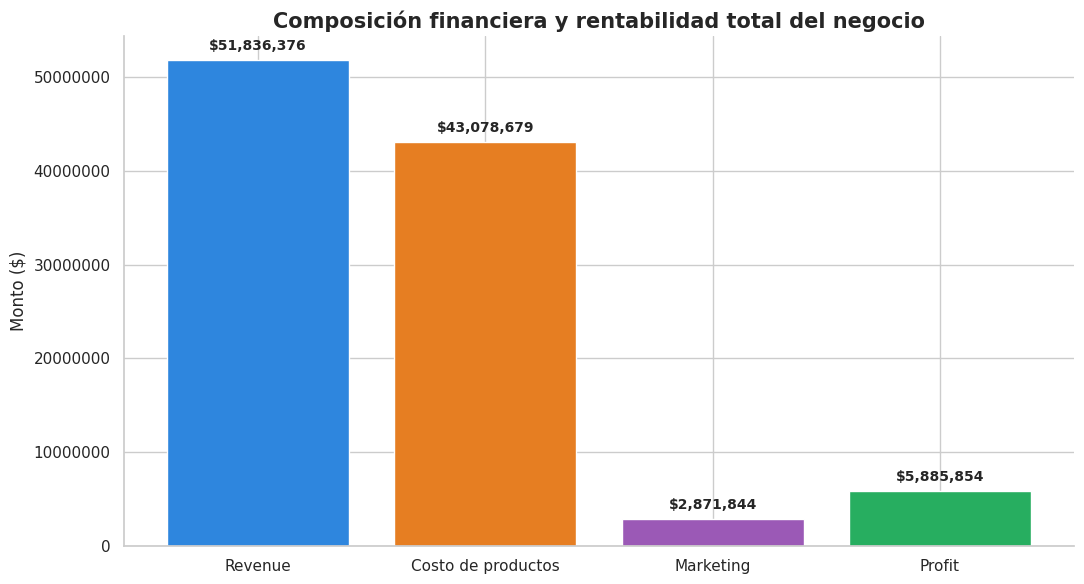

In [60]:
# Gráfica 1: composición financiera y rentabilidad

metricas_financieras = pd.DataFrame({
    "Métrica": [
        "Revenue",
        "Costo de productos",
        "Marketing",
        "Profit"
    ],
    "Monto": [
        revenue_total,
        costo_total,
        marketing_total,
        profit_total
    ]
})

colores = [
    "#2E86DE",
    "#E67E22",
    "#9B59B6",
    "#27AE60" if profit_total >= 0 else "#C0392B"
]

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.bar(
    metricas_financieras["Métrica"],
    metricas_financieras["Monto"],
    color=colores
)

ax.set_title(
    "Composición financiera y rentabilidad total del negocio",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Monto ($)")

ax.ticklabel_format(
    style="plain",
    axis="y"
)

for barra, valor in zip(
    barras,
    metricas_financieras["Monto"]
):
    ax.annotate(
        f"${valor:,.0f}",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretación de la rentabilidad

Durante el periodo analizado, el negocio generó un revenue total de
**$51.84 millones**. El costo de los productos fue de **$43.08 millones**
y la inversión en marketing alcanzó **$2.87 millones**.

Después de descontar ambos conceptos, se obtuvo un profit de
**$5.89 millones**, equivalente a un margen aproximado de **11.35%**.

Por lo tanto, considerando todos los registros del dataset, el negocio
es rentable. Sin embargo, la mayor parte de los ingresos se utiliza para
cubrir el costo de los productos, por lo que conviene revisar los márgenes
por producto y los pedidos con cantidades atípicamente elevadas.

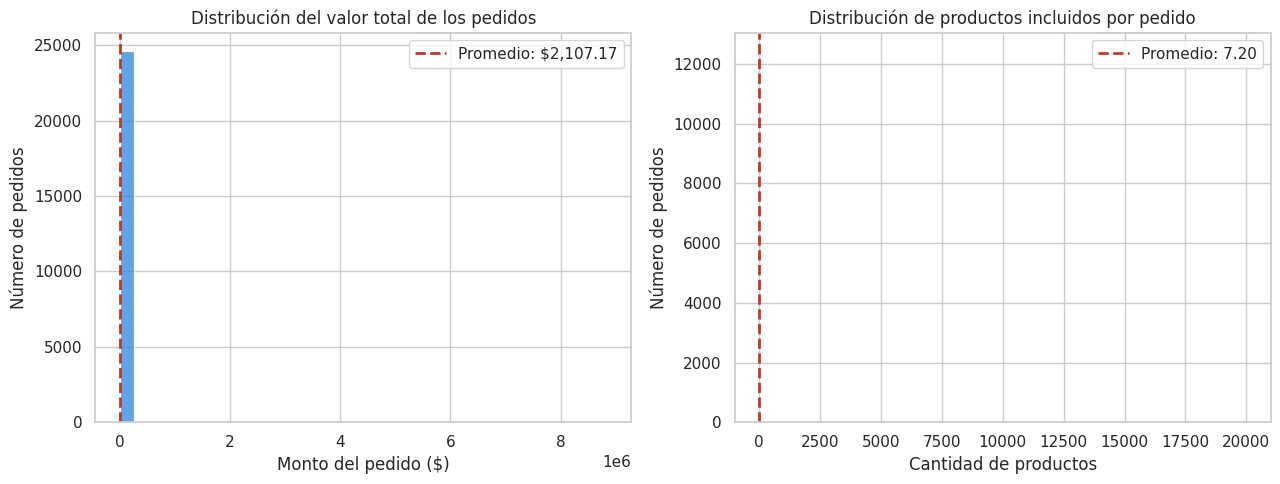

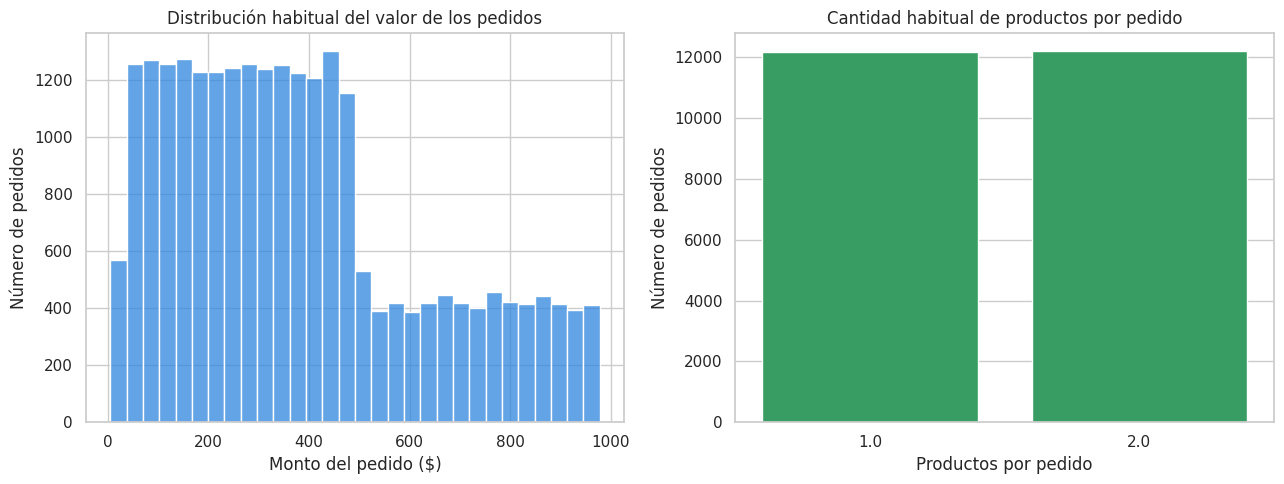

In [68]:
# Gráfica 2: ticket y cantidad de productos por pedido

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# Distribución del ticket por pedido

sns.histplot(
    data=resumen_pedidos,
    x="ingreso_pedido",
    bins=35,
    color="#2E86DE",
    ax=axes[0]
)

axes[0].axvline(
    ticket_promedio,
    color="#C0392B",
    linestyle="--",
    linewidth=2,
    label=f"Promedio: ${ticket_promedio:,.2f}"
)

axes[0].set_title(
    "Distribución del valor total de los pedidos"
)
axes[0].set_xlabel("Monto del pedido ($)")
axes[0].set_ylabel("Número de pedidos")
axes[0].legend()


# Distribución de productos por pedido

sns.histplot(
    data=resumen_pedidos,
    x="productos_pedido",
    discrete=True,
    color="#27AE60",
    ax=axes[1]
)

axes[1].axvline(
    productos_promedio,
    color="#C0392B",
    linestyle="--",
    linewidth=2,
    label=f"Promedio: {productos_promedio:,.2f}"
)

axes[1].set_title(
    "Distribución de productos incluidos por pedido"
)
axes[1].set_xlabel("Cantidad de productos")
axes[1].set_ylabel("Número de pedidos")
axes[1].legend()

plt.tight_layout()
plt.show()

limite_ticket = resumen_pedidos[
    "ingreso_pedido"
].quantile(0.99)

limite_productos = resumen_pedidos[
    "productos_pedido"
].quantile(0.99)

pedidos_habituales = resumen_pedidos[
    (resumen_pedidos["ingreso_pedido"] <= limite_ticket)
    & 
    (resumen_pedidos["productos_pedido"] <= limite_productos)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=pedidos_habituales,
    x="ingreso_pedido",
    bins=30,
    color="#2E86DE",
    ax=axes[0]
)

axes[0].set_title(
    "Distribución habitual del valor de los pedidos"
)
axes[0].set_xlabel("Monto del pedido ($)")
axes[0].set_ylabel("Número de pedidos")


sns.countplot(
    data=pedidos_habituales,
    x="productos_pedido",
    color="#27AE60",
    ax=axes[1]
)

axes[1].set_title(
    "Cantidad habitual de productos por pedido"
)
axes[1].set_xlabel("Productos por pedido")
axes[1].set_ylabel("Número de pedidos")

plt.tight_layout()
plt.show()

### Interpretación del comportamiento de compra

El ticket promedio considerando todos los pedidos es de **$2,107.17**,
mientras que la cantidad promedio es de **7.20 productos por orden**.

Sin embargo, ambos promedios están influenciados por pedidos atípicos
de laptops con cantidades de 10,000 y 20,000 unidades. La mediana del
ticket es de aproximadamente **$341.71** y la cantidad habitual por
pedido se encuentra entre uno y dos productos.

Esto indica que la compra típica es considerablemente menor que el
promedio general y que existen algunas operaciones de volumen
extraordinario que elevan los indicadores.

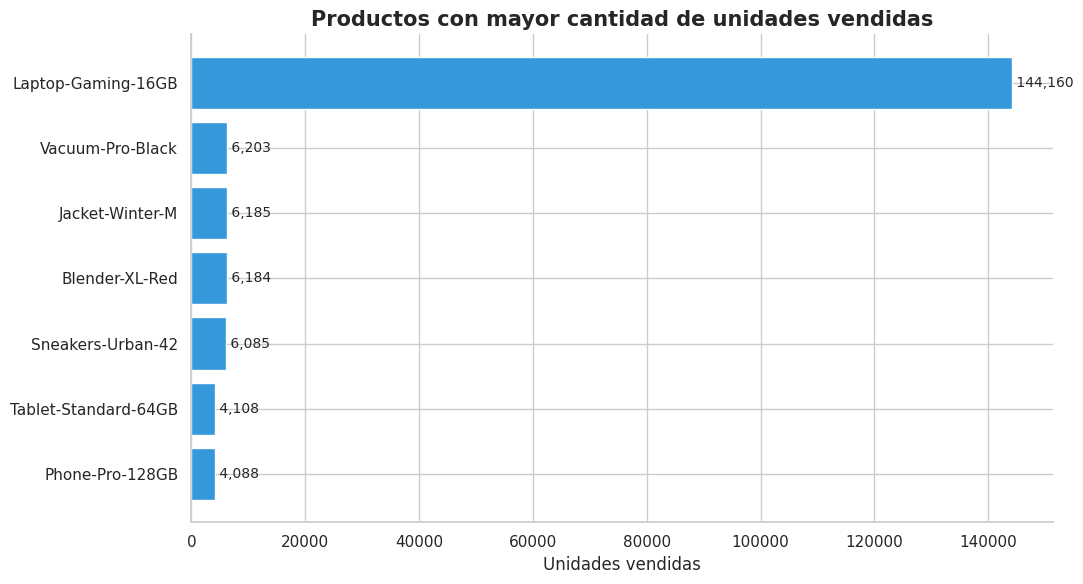

In [69]:
# Gráfica 3: producto más vendido

ventas_producto = (
    orders_analysis
    .groupby("nombre_producto", as_index=False)
    .agg(
        unidades_vendidas=("cantidad", "sum"),
        ingresos=("monto_total", "sum")
    )
    .sort_values(
        "unidades_vendidas",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(
    ventas_producto["nombre_producto"],
    ventas_producto["unidades_vendidas"],
    color="#3498DB"
)

ax.set_title(
    "Productos con mayor cantidad de unidades vendidas",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Unidades vendidas")
ax.set_ylabel("")

for barra, valor in zip(
    barras,
    ventas_producto["unidades_vendidas"]
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f" {valor:,.0f}",
        va="center",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()    

### Interpretación de productos vendidos

El producto con mayor cantidad registrada es
**Laptop-Gaming-16GB**, con **144,160 unidades**.

No obstante, este resultado está fuertemente concentrado en diez pedidos
atípicos de entre 10,000 y 20,000 unidades. Por este motivo, antes de tomar
una decisión comercial se recomienda confirmar si corresponden a ventas
mayoristas reales o a errores de captura.

Entre los productos con un comportamiento más habitual, destacan
Vacuum-Pro-Black, Jacket-Winter-M y Blender-XL-Red, con aproximadamente
6,200 unidades vendidas cada uno.

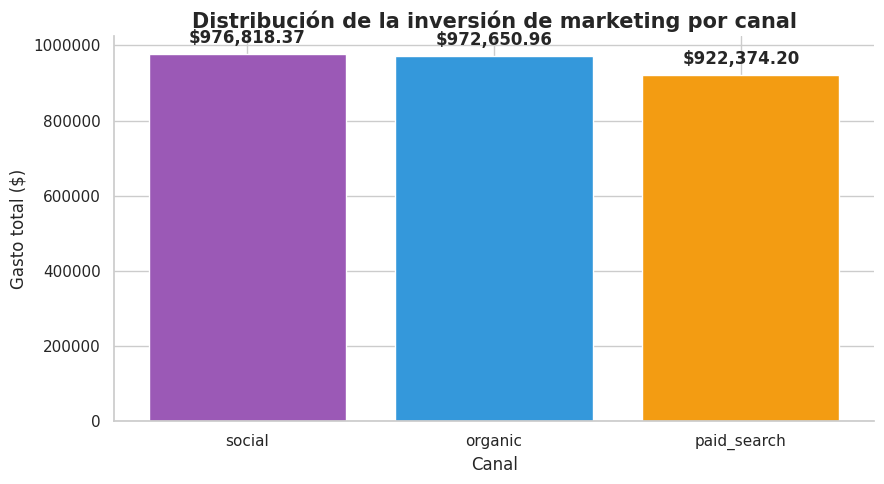

,canal,gasto_total
2,social,976818.37
0,organic,972650.96
1,paid_search,922374.20


In [87]:
# Gráfica 4: gasto de marketing por canal

marketing_canal = (
    marketing_spend
    .groupby("canal", as_index=False)
    .agg(gasto_total=("gasto", "sum"))
    .sort_values(
        "gasto_total",
        ascending=False
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    marketing_canal["canal"],
    marketing_canal["gasto_total"],
    color=["#9B59B6", "#3498DB", "#F39C12"]
)

ax.set_title(
    "Distribución de la inversión de marketing por canal",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Canal")
ax.set_ylabel("Gasto total ($)")

ax.ticklabel_format(
    style="plain",
    axis="y"
)

for barra, valor in zip(
    barras,
    marketing_canal["gasto_total"]
):
    ax.annotate(
        f"${valor:,.2f}",
        xy=(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

marketing_canal

### 2.5 Interpretación de la inversión en marketing

El canal con mayor gasto acumulado es **social**, con aproximadamente
**$976.82 mil**, seguido muy de cerca por **organic**, con **$972.65 mil**.
El canal **paid_search** presenta el menor gasto, con **$922.37 mil**.

La inversión está distribuida de forma relativamente equilibrada entre
los tres canales. Sin embargo, el gasto por sí solo no permite determinar
qué canal es más eficiente. Para tomar decisiones de asignación de
presupuesto sería necesario comparar esta inversión con los ingresos,
pedidos o conversiones atribuidos a cada canal.

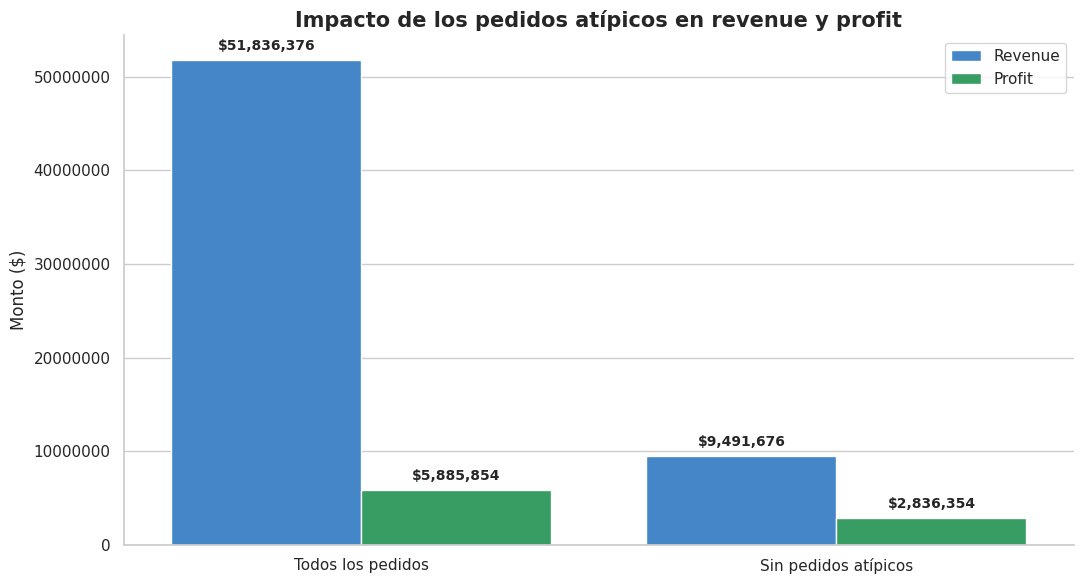

RESULTADOS DE LA COMPARACIÓN
---------------------------------------------
Revenue con todos los pedidos: $51,836,375.92
Profit con todos los pedidos: $5,885,853.59
Revenue sin pedidos atípicos: $9,491,675.92
Profit sin pedidos atípicos: $2,836,353.59
Cantidad de pedidos atípicos: 10


In [73]:
# Gráfica efecto de pedidos atípicos

# Identificar pedidos con cantidades atípicas
pedidos_atipicos = orders_analysis[
    orders_analysis["cantidad"] > 2
].copy()


# Calcular métricas utilizando todos los pedidos
revenue_con_atipicos = orders_analysis[
    "monto_total"
].sum()

costo_con_atipicos = orders_analysis[
    "costo_productos"
].sum()

profit_con_atipicos = (
    revenue_con_atipicos
    - costo_con_atipicos
    - marketing_total
)


# Crear dataset sin pedidos atípicos
orders_sin_atipicos = orders_analysis[
    orders_analysis["cantidad"] <= 2
].copy()


# Calcular métricas sin pedidos atípicos
revenue_sin_atipicos = orders_sin_atipicos[
    "monto_total"
].sum()

costo_sin_atipicos = orders_sin_atipicos[
    "costo_productos"
].sum()

profit_sin_atipicos = (
    revenue_sin_atipicos
    - costo_sin_atipicos
    - marketing_total
)


# Crear tabla comparativa
comparacion_atipicos = pd.DataFrame({
    "Escenario": [
        "Todos los pedidos",
        "Sin pedidos atípicos"
    ],
    "Revenue": [
        revenue_con_atipicos,
        revenue_sin_atipicos
    ],
    "Profit": [
        profit_con_atipicos,
        profit_sin_atipicos
    ]
})


# Convertir la tabla a formato largo para Seaborn
comparacion_larga = comparacion_atipicos.melt(
    id_vars="Escenario",
    var_name="Métrica",
    value_name="Monto"
)


# Crear la gráfica
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=comparacion_larga,
    x="Escenario",
    y="Monto",
    hue="Métrica",
    palette={
        "Revenue": "#2E86DE",
        "Profit": "#27AE60"
    },
    ax=ax
)


# Configurar títulos y ejes
ax.set_title(
    "Impacto de los pedidos atípicos en revenue y profit",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Monto ($)")

ax.ticklabel_format(
    style="plain",
    axis="y"
)


# Agregar etiquetas manualmente sobre las barras
for container in ax.containers:
    for barra in container:
        altura = barra.get_height()

        ax.annotate(
            f"${altura:,.0f}",
            xy=(
                barra.get_x() + barra.get_width() / 2,
                altura
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )


# Ajustar la leyenda y el diseño
ax.legend(
    title="",
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# Mostrar resultados numéricos
print("RESULTADOS DE LA COMPARACIÓN")
print("-" * 45)

print(
    f"Revenue con todos los pedidos: "
    f"${revenue_con_atipicos:,.2f}"
)

print(
    f"Profit con todos los pedidos: "
    f"${profit_con_atipicos:,.2f}"
)

print(
    f"Revenue sin pedidos atípicos: "
    f"${revenue_sin_atipicos:,.2f}"
)

print(
    f"Profit sin pedidos atípicos: "
    f"${profit_sin_atipicos:,.2f}"
)

print(
    f"Cantidad de pedidos atípicos: "
    f"{len(pedidos_atipicos):,}"
)

### Interpretación del impacto de los pedidos atípicos

Al comparar ambos escenarios, se observa que los pedidos atípicos tienen un impacto considerable en los resultados financieros. Al incluir todos los registros, el negocio genera un **revenue de 51.84 millones** y un **profit de 5.89 millones**.

Al excluir temporalmente los **10 pedidos atípicos**, correspondientes a cantidades de entre **10,000 y 20,000 laptops**, el revenue disminuye a **9.49 millones** y el profit a **2.84 millones**.

Aunque estos pedidos representan aproximadamente **42.34 millones del revenue total**, el negocio continúa siendo rentable aun sin considerarlos. De hecho, el margen de profit aumenta aproximadamente de **11.35% a 29.88%**, lo que indica que estas ventas extraordinarias aportan ingresos y utilidad, pero operan con un margen proporcionalmente menor que los pedidos habituales.

Los registros no fueron eliminados del análisis principal porque no existe evidencia suficiente para clasificarlos como errores. Sin embargo, debido a su magnitud y a su influencia sobre el revenue, el ticket promedio y la cantidad promedio de productos por orden, se recomienda confirmar con el área comercial si corresponden a ventas mayoristas reales o a errores de captura antes de tomar decisiones estratégicas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre es importante tener un proceso de análisis claro y fácil de entender en todos tus notebooks para que cuando alguien de tu equipo quiera reproducir tu trabajo puedan entenderlo facilmente.
</div>

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [75]:

import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})


In [76]:

# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()


,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [77]:

# PARTE 1: Totales del funnel
# ===========================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
WHERE nombre_evento IN (
    'first_visit',
    'select_item',
    'add_to_cart',
    'begin_checkout',
    'add_payment_info',
    'purchase'
)
GROUP BY nombre_evento
ORDER BY
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'select_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase' THEN 6
    END;
'''

totals = pd.read_sql(query_totals, con=engine)

totals


,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7582
2,add_to_cart,7634
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [78]:

# PARTE 2: Conversiones
# =====================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,

        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
        END AS orden_etapa

    FROM events

    WHERE nombre_evento IN (
        'first_visit',
        'select_item',
        'add_to_cart',
        'begin_checkout',
        'add_payment_info',
        'purchase'
    )

    GROUP BY nombre_evento
),

comparacion AS (
    SELECT
        nombre_evento,
        usuarios_unicos,
        orden_etapa,

        LAG(usuarios_unicos) OVER (
            ORDER BY orden_etapa
        ) AS usuarios_etapa_anterior,

        FIRST_VALUE(usuarios_unicos) OVER (
            ORDER BY orden_etapa
        ) AS usuarios_primera_etapa

    FROM funnel
)

SELECT
    nombre_evento,
    usuarios_unicos,

    COALESCE(
        usuarios_etapa_anterior - usuarios_unicos,
        0
    ) AS usuarios_perdidos,

    ROUND(
        COALESCE(
            usuarios_unicos * 100.0
            / NULLIF(usuarios_etapa_anterior, 0),
            100
        ),
        2
    ) AS conversion_etapa_anterior_pct,

    ROUND(
        COALESCE(
            (usuarios_etapa_anterior - usuarios_unicos) * 100.0
            / NULLIF(usuarios_etapa_anterior, 0),
            0
        ),
        2
    ) AS drop_off_pct,

    ROUND(
        usuarios_unicos * 100.0
        / NULLIF(usuarios_primera_etapa, 0),
        2
    ) AS conversion_acumulada_pct

FROM comparacion
ORDER BY orden_etapa;
'''

conversion = pd.read_sql(
    query_conversion,
    con=engine
)

conversion


,nombre_evento,usuarios_unicos,usuarios_perdidos,conversion_etapa_anterior_pct,drop_off_pct,conversion_acumulada_pct
0,first_visit,7796,0,100.00,0.00,100.00
1,select_item,7582,214,97.26,2.74,97.26
2,add_to_cart,7634,-52,100.69,-0.69,97.92
3,begin_checkout,7208,426,94.42,5.58,92.46
4,add_payment_info,6250,958,86.71,13.29,80.17
5,purchase,6240,10,99.84,0.16,80.04


In [79]:

# identificar el mayor abandono y la conversión final

mayor_drop_off = conversion.loc[
    conversion['usuarios_perdidos'].idxmax()
]

conversion_final = conversion.loc[
    conversion['nombre_evento'] == 'purchase',
    'conversion_acumulada_pct'
].iloc[0]

print('ANÁLISIS DEL FUNNEL')
print('===================')

print(
    'Etapa con mayor pérdida:',
    mayor_drop_off['nombre_evento']
)

print(
    'Usuarios perdidos:',
    f"{mayor_drop_off['usuarios_perdidos']:,.0f}"
)

print(
    'Drop-off de la etapa:',
    f"{mayor_drop_off['drop_off_pct']:.2f}%"
)

print(
    'Tasa de conversión final:',
    f"{conversion_final:.2f}%"
)


ANÁLISIS DEL FUNNEL
Etapa con mayor pérdida: add_payment_info
Usuarios perdidos: 958
Drop-off de la etapa: 13.29%
Tasa de conversión final: 80.04%


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto el cálculo realizado sobre las conversiones. Aquí lo único que agregaría sería una visualización para complementar los resultados y que sea más sencillo explicar los resultados obtenidos del funnel.
</div>


<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 


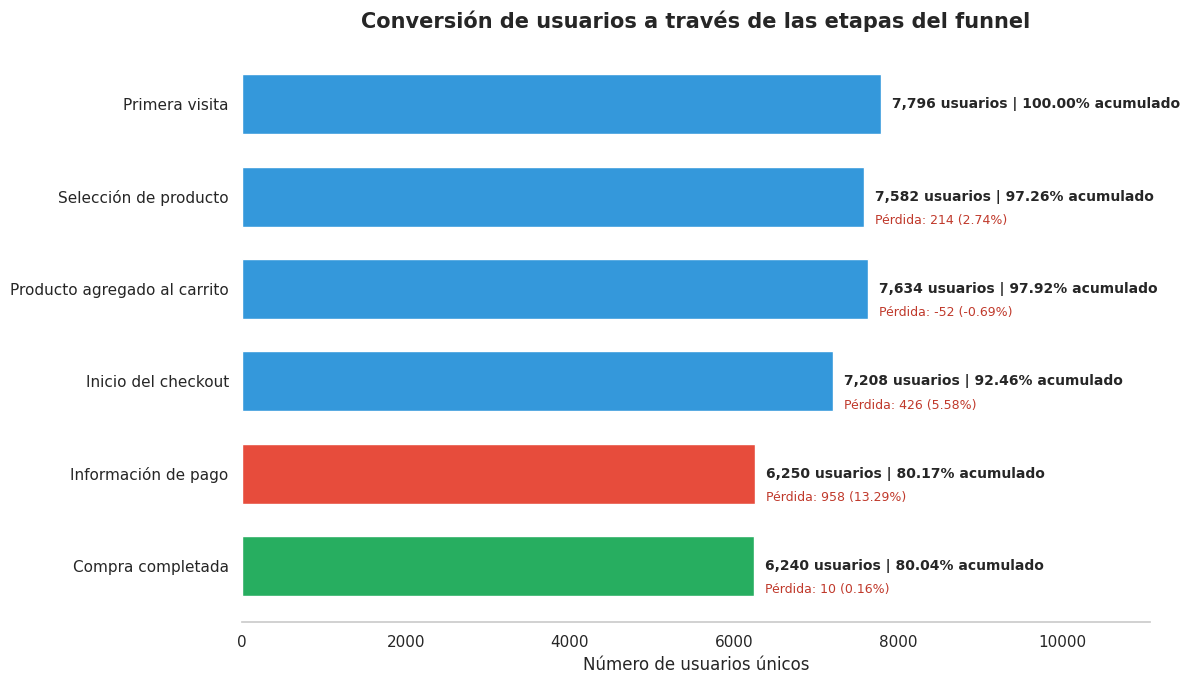

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear copia para no modificar el DataFrame original
funnel_grafica = conversion.copy().reset_index(drop=True)

# Convertir columnas a valores numéricos
columnas_numericas = [
    "usuarios_unicos",
    "usuarios_perdidos",
    "conversion_etapa_anterior_pct",
    "drop_off_pct",
    "conversion_acumulada_pct"
]

for columna in columnas_numericas:
    funnel_grafica[columna] = pd.to_numeric(
        funnel_grafica[columna],
        errors="coerce"
    )

# Nombres más claros para mostrar en la gráfica
nombres_etapas = {
    "first_visit": "Primera visita",
    "select_item": "Selección de producto",
    "add_to_cart": "Producto agregado al carrito",
    "begin_checkout": "Inicio del checkout",
    "add_payment_info": "Información de pago",
    "purchase": "Compra completada"
}

funnel_grafica["etapa"] = funnel_grafica[
    "nombre_evento"
].map(nombres_etapas)

# Colores: destacar la etapa con mayor pérdida
colores = []

for indice, fila in funnel_grafica.iterrows():

    if fila["nombre_evento"] == mayor_drop_off["nombre_evento"]:
        colores.append("#E74C3C")
    elif fila["nombre_evento"] == "purchase":
        colores.append("#27AE60")
    else:
        colores.append("#3498DB")

# Crear gráfica
fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.barh(
    funnel_grafica["etapa"],
    funnel_grafica["usuarios_unicos"],
    color=colores,
    height=0.65
)

# Colocar la primera etapa en la parte superior
ax.invert_yaxis()

# Ampliar espacio para las etiquetas
maximo_usuarios = funnel_grafica["usuarios_unicos"].max()

ax.set_xlim(
    0,
    maximo_usuarios * 1.42
)

# Agregar etiquetas a cada barra
for indice, barra in enumerate(barras):

    usuarios = funnel_grafica.loc[
        indice,
        "usuarios_unicos"
    ]

    conversion_acumulada = funnel_grafica.loc[
        indice,
        "conversion_acumulada_pct"
    ]

    usuarios_perdidos = funnel_grafica.loc[
        indice,
        "usuarios_perdidos"
    ]

    drop_off = funnel_grafica.loc[
        indice,
        "drop_off_pct"
    ]

    # Etiqueta principal
    etiqueta = (
        f"{usuarios:,.0f} usuarios | "
        f"{conversion_acumulada:.2f}% acumulado"
    )

    ax.annotate(
        etiqueta,
        xy=(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2
        ),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    # Mostrar abandono desde la segunda etapa
    if indice > 0:

        etiqueta_perdida = (
            f"Pérdida: {usuarios_perdidos:,.0f} "
            f"({drop_off:.2f}%)"
        )

        ax.annotate(
            etiqueta_perdida,
            xy=(
                barra.get_width(),
                barra.get_y() + barra.get_height() / 2
            ),
            xytext=(8, -17),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
            color="#C0392B"
        )

# Títulos y ejes
ax.set_title(
    "Conversión de usuarios a través de las etapas del funnel",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Número de usuarios únicos")
ax.set_ylabel("")

# Mostrar números completos en el eje X
ax.ticklabel_format(
    style="plain",
    axis="x"
)

# Quitar bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Cuadrícula ligera
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()
plt.show()

---

### Interpretación del funnel de conversión

El funnel muestra una reducción progresiva en el número de usuarios conforme avanzan desde la primera visita hasta la compra. A pesar de esta disminución, la tasa de conversión acumulada final es de <b>80.04%</b>, lo que significa que aproximadamente ocho de cada diez usuarios que iniciaron el recorrido completaron una compra.

La mayor pérdida se presenta en la transición entre <b>Inicio del checkout</b> e <b>Información de pago</b>. En este punto abandonaron el proceso <b>958 usuarios</b>, lo que representa un drop-off de <b>13.29%</b> respecto a la etapa anterior.

Este resultado indica que el registro de la información de pago es el principal punto de fricción del proceso de compra. Algunas causas posibles podrían ser un formulario demasiado extenso, problemas técnicos, falta de métodos de pago, costos adicionales inesperados o inquietudes relacionadas con la seguridad.

Se recomienda revisar esta etapa mediante pruebas de usabilidad, análisis de errores y segmentación por dispositivo. También sería conveniente simplificar el formulario, mostrar con anticipación el costo total de la compra y ofrecer diferentes métodos de pago.

En conclusión, el funnel presenta una conversión final elevada, pero optimizar la etapa de información de pago podría recuperar una parte importante de los usuarios perdidos y aumentar el número de compras completadas.

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)
        
**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.
    
**Tablas**
    
- `users` 
- `user_activity` 
    
---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.
    
    
2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
       - `retenido_w1`: usuarios activos en la semana 1  
       - `retenido_w2`: usuarios activos en la semana 2  
       - `retenido_w3`: usuarios activos en la semana 3  
    
    
3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
       - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
       - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
       - `semana_3`: porcentaje de usuarios retenidos en la semana 3  
    
Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`


In [81]:

# Explorar tabla users
# =====================

query_users = '''
SELECT *
FROM users
LIMIT 5;
'''

users = pd.read_sql(
    query_users,
    con=engine
)

users.head(3)


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [84]:

# Explorar tabla user_activity
# ============================

query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 5;
'''

user_activity = pd.read_sql(
    query_user_activity,
    con=engine
)

user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [85]:

# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH actividad_por_usuario AS (
    SELECT
        u.id_usuario,

        DATE_TRUNC(
            'month',
            CAST(u.fecha_registro AS DATE)
        )::DATE AS cohorte,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro BETWEEN 1 AND 7
                THEN 1
                ELSE 0
            END
        ) AS retenido_w1,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro BETWEEN 8 AND 14
                THEN 1
                ELSE 0
            END
        ) AS retenido_w2,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro BETWEEN 15 AND 21
                THEN 1
                ELSE 0
            END
        ) AS retenido_w3

    FROM users AS u

    LEFT JOIN user_activity AS ua
        ON u.id_usuario = ua.id_usuario

    GROUP BY
        u.id_usuario,
        DATE_TRUNC(
            'month',
            CAST(u.fecha_registro AS DATE)
        )::DATE
),

retencion_por_cohorte AS (
    SELECT
        cohorte,
        COUNT(*) AS usuarios_iniciales,
        SUM(retenido_w1) AS retenido_w1,
        SUM(retenido_w2) AS retenido_w2,
        SUM(retenido_w3) AS retenido_w3

    FROM actividad_por_usuario
    GROUP BY cohorte
)

SELECT
    cohorte,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,

    ROUND(
        retenido_w1 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_1,

    ROUND(
        retenido_w2 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_2,

    ROUND(
        retenido_w3 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_3

FROM retencion_por_cohorte
ORDER BY cohorte;
'''

# Ejecutar la consulta

cohorte_final = pd.read_sql(
    query_cohort_retention_final,
    con=engine
)

cohorte_final


,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01,1687,695,676,706,41.20,40.07,41.85


---

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La query está muy bien y estás obteniendo resultados adecuados pero lo complementarías mejor si agregaras una visualización.
</div>


<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 


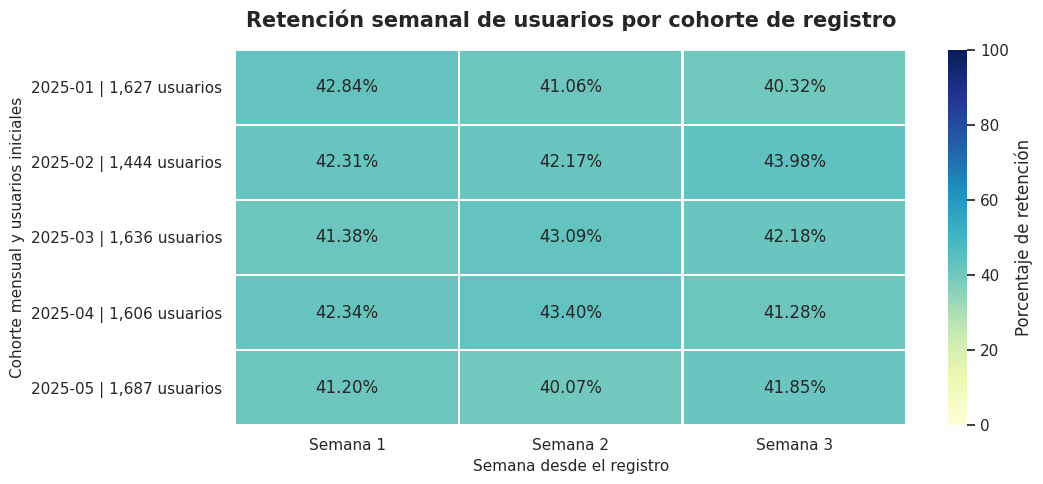

RESUMEN DE RETENCIÓN
Retención promedio en semana 1: 42.01%
Retención promedio en semana 2: 41.96%
Retención promedio en semana 3: 41.92%
Cohorte con mayor retención en semana 3: 2025-02
Retención de esa cohorte: 43.98%


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================
# 1. Consultar la retención por cohortes
# =====================================================

query_cohort_retention_grafica = """
WITH actividad_por_usuario AS (
    SELECT
        u.id_usuario,

        DATE_TRUNC(
            'month',
            CAST(u.fecha_registro AS DATE)
        )::DATE AS cohorte,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro
                         BETWEEN 1 AND 7
                THEN 1
                ELSE 0
            END
        ) AS retenido_w1,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro
                         BETWEEN 8 AND 14
                THEN 1
                ELSE 0
            END
        ) AS retenido_w2,

        MAX(
            CASE
                WHEN ua.activo = 1
                     AND ua.dias_despues_registro
                         BETWEEN 15 AND 21
                THEN 1
                ELSE 0
            END
        ) AS retenido_w3

    FROM users AS u

    LEFT JOIN user_activity AS ua
        ON u.id_usuario = ua.id_usuario

    GROUP BY
        u.id_usuario,
        DATE_TRUNC(
            'month',
            CAST(u.fecha_registro AS DATE)
        )::DATE
),

retencion_por_cohorte AS (
    SELECT
        cohorte,
        COUNT(*) AS usuarios_iniciales,
        SUM(retenido_w1) AS retenido_w1,
        SUM(retenido_w2) AS retenido_w2,
        SUM(retenido_w3) AS retenido_w3

    FROM actividad_por_usuario

    GROUP BY cohorte
)

SELECT
    cohorte,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,

    ROUND(
        retenido_w1 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_1,

    ROUND(
        retenido_w2 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_2,

    ROUND(
        retenido_w3 * 100.0
        / NULLIF(usuarios_iniciales, 0),
        2
    ) AS semana_3

FROM retencion_por_cohorte

ORDER BY cohorte;
"""


# Ejecutar consulta
cohorte_final = pd.read_sql(
    query_cohort_retention_grafica,
    con=engine
)


# =====================================================
# 2. Preparar los datos
# =====================================================

# Convertir la cohorte a fecha
cohorte_final["cohorte"] = pd.to_datetime(
    cohorte_final["cohorte"]
)


# Convertir las columnas de retención a valores numéricos
columnas_retencion = [
    "semana_1",
    "semana_2",
    "semana_3"
]

for columna in columnas_retencion:
    cohorte_final[columna] = pd.to_numeric(
        cohorte_final[columna],
        errors="coerce"
    )


# Convertir usuarios iniciales a número
cohorte_final["usuarios_iniciales"] = pd.to_numeric(
    cohorte_final["usuarios_iniciales"],
    errors="coerce"
)


# Ordenar por cohorte
cohorte_final = cohorte_final.sort_values(
    "cohorte"
).reset_index(drop=True)


# Crear etiquetas con cohorte y tamaño inicial
cohorte_final["etiqueta_cohorte"] = (
    cohorte_final["cohorte"].dt.strftime("%Y-%m")
    +
    " | "
    +
    cohorte_final["usuarios_iniciales"]
    .fillna(0)
    .astype(int)
    .map("{:,}".format)
    +
    " usuarios"
)


# Crear matriz para el mapa de calor
matriz_retencion = cohorte_final.set_index(
    "etiqueta_cohorte"
)[
    [
        "semana_1",
        "semana_2",
        "semana_3"
    ]
].copy()


# Cambiar nombres de las columnas
matriz_retencion.columns = [
    "Semana 1",
    "Semana 2",
    "Semana 3"
]


# =====================================================
# 3. Crear etiquetas porcentuales
# =====================================================

anotaciones = matriz_retencion.copy()

for columna in anotaciones.columns:
    anotaciones[columna] = anotaciones[columna].apply(
        lambda valor: (
            f"{valor:.2f}%"
            if pd.notna(valor)
            else ""
        )
    )


# =====================================================
# 4. Crear mapa de calor
# =====================================================

alto_grafica = max(
    5,
    len(matriz_retencion) * 0.75
)

fig, ax = plt.subplots(
    figsize=(11, alto_grafica)
)

sns.heatmap(
    matriz_retencion,
    annot=anotaciones,
    fmt="",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label": "Porcentaje de retención"
    },
    ax=ax
)


# =====================================================
# 5. Personalizar la gráfica
# =====================================================

ax.set_title(
    "Retención semanal de usuarios por cohorte de registro",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Semana desde el registro",
    fontsize=11
)

ax.set_ylabel(
    "Cohorte mensual y usuarios iniciales",
    fontsize=11
)

# Mantener horizontales las etiquetas
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()


# =====================================================
# 6. Mostrar resumen general
# =====================================================

promedio_semana_1 = cohorte_final[
    "semana_1"
].mean()

promedio_semana_2 = cohorte_final[
    "semana_2"
].mean()

promedio_semana_3 = cohorte_final[
    "semana_3"
].mean()


print("RESUMEN DE RETENCIÓN")
print("====================")

print(
    "Retención promedio en semana 1:",
    f"{promedio_semana_1:.2f}%"
)

print(
    "Retención promedio en semana 2:",
    f"{promedio_semana_2:.2f}%"
)

print(
    "Retención promedio en semana 3:",
    f"{promedio_semana_3:.2f}%"
)


# Identificar la cohorte con mayor retención en semana 3
indice_mejor_cohorte = cohorte_final[
    "semana_3"
].idxmax()

mejor_cohorte = cohorte_final.loc[
    indice_mejor_cohorte
]

print(
    "Cohorte con mayor retención en semana 3:",
    mejor_cohorte["cohorte"].strftime("%Y-%m")
)

print(
    "Retención de esa cohorte:",
    f"{mejor_cohorte['semana_3']:.2f}%"
)

### Interpretación de la retención por cohortes

La retención de usuarios se mantiene relativamente estable durante las tres semanas analizadas. La retención promedio es de <b>42.01% en la semana 1</b>, <b>41.96% en la semana 2</b> y <b>41.92% en la semana 3</b>.

Esto significa que aproximadamente <b>4 de cada 10 usuarios registrados regresan y permanecen activos</b> durante cada una de las primeras tres semanas. La diferencia entre la semana 1 y la semana 3 es de solo <b>0.09 puntos porcentuales</b>, por lo que no se observa una caída general significativa conforme transcurre el tiempo.

La cohorte de <b>febrero de 2025</b> presenta el mejor resultado en la semana 3, con una retención de <b>43.98%</b>. Además, esta cohorte mejora respecto a la semana 1, cuando registró una retención de 42.31%.

Por el contrario, la cohorte de <b>enero de 2025</b> presenta la menor retención en la semana 3, con <b>40.32%</b>, después de disminuir desde 42.84% en la primera semana.

La cohorte de <b>mayo de 2025</b> tiene la mayor cantidad inicial, con <b>1,687 usuarios</b>. Su retención disminuye en la segunda semana, pero se recupera hasta <b>41.85%</b> en la semana 3.

En general, no existe una cohorte con un deterioro continuo y pronunciado. Los porcentajes permanecen dentro de un intervalo relativamente reducido, aproximadamente entre <b>40% y 44%</b>, lo que indica un comportamiento consistente entre los distintos meses de registro.

Como acción de negocio, se recomienda analizar las campañas, promociones y características de los usuarios registrados en <b>febrero de 2025</b> para identificar qué factores contribuyeron a su mayor retención. También conviene implementar comunicaciones, recordatorios o incentivos durante las primeras semanas para intentar elevar la retención general por encima del nivel actual.

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  


### Hipótesis estadística

- **H₀ (hipótesis nula):** La tasa de conversión del grupo de tratamiento es igual a la tasa de conversión del grupo de control. La modificación de la interfaz del checkout no genera un impacto estadísticamente significativo.

- **H₁ (hipótesis alternativa):** La tasa de conversión del grupo de tratamiento es diferente de la tasa de conversión del grupo de control. La modificación de la interfaz del checkout sí genera un impacto estadísticamente significativo.

**Test estadístico:** Z-test de dos proporciones.

**Nivel de significancia:** α = 0.05.

In [35]:
# tu código aquí
# Cargar y explorar el Dataset
# importar librerías

import pandas as pd
import numpy as np

from statsmodels.stats.proportion import proportions_ztest

# cargar el dataset del experimento

url_experiment = (
    'https://practicum-content.s3.amazonaws.com/'
    'datasets/experiment_checkout_ui.csv'
)

experiment = pd.read_csv(url_experiment)

display(experiment.head())
experiment.info()


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [36]:
# Revisar la Calidad de los Datos
# convertir timestamp a formato fecha

experiment['timestamp'] = pd.to_datetime(
    experiment['timestamp'],
    errors='coerce'
)

# normalizar variables categóricas

columnas_categoricas = [
    'id_usuario',
    'variante',
    'dispositivo',
    'pais'
]

for columna in columnas_categoricas:
    experiment[columna] = (
        experiment[columna]
        .astype('string')
        .str.strip()
        .str.lower()
    )

print('Dimensiones:', experiment.shape)

print('\nValores ausentes:')
print(experiment.isna().sum())

print(
    '\nFilas duplicadas:',
    experiment.duplicated().sum()
)

print('\nValores de variante:')
print(experiment['variante'].value_counts(dropna=False))

print('\nValores de conversión:')
print(experiment['convirtio'].value_counts(dropna=False))


Dimensiones: (10000, 7)

Valores ausentes:
id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64

Filas duplicadas: 0

Valores de variante:
tratamiento    5035
control        4965
Name: variante, dtype: Int64

Valores de conversión:
0    8401
1    1599
Name: convirtio, dtype: int64


In [37]:
# Verificar la asignacion del experimento
# comprobar si un usuario aparece en más de una variante

variantes_por_usuario = (
    experiment
    .groupby('id_usuario')['variante']
    .nunique()
)

usuarios_en_ambas_variantes = (
    variantes_por_usuario > 1
).sum()

print(
    'Usuarios presentes en más de una variante:',
    usuarios_en_ambas_variantes
)

print(
    'Usuarios únicos:',
    experiment['id_usuario'].nunique()
)

Usuarios presentes en más de una variante: 0
Usuarios únicos: 10000


In [38]:
# Limoiar Registros invalidos
# eliminar duplicados exactos

experiment = (
    experiment
    .drop_duplicates()
    .reset_index(drop=True)
)

# conservar registros con datos indispensables válidos

experiment = experiment.dropna(
    subset=[
        'id_usuario',
        'variante',
        'convirtio',
        'timestamp'
    ]
).copy()

# conservar únicamente las dos variantes esperadas

experiment = experiment[
    experiment['variante'].isin(
        ['control', 'tratamiento']
    )
].copy()

# conservar únicamente valores binarios de conversión

experiment = experiment[
    experiment['convirtio'].isin([0, 1])
].copy()

# excluir usuarios asignados a las dos variantes

usuarios_conflictivos = (
    experiment
    .groupby('id_usuario')['variante']
    .nunique()
)

usuarios_conflictivos = usuarios_conflictivos[
    usuarios_conflictivos > 1
].index

experiment = experiment[
    ~experiment['id_usuario'].isin(usuarios_conflictivos)
].copy()

print('Dimensiones después de la limpieza:', experiment.shape)
print('Valores ausentes:', experiment.isna().sum().sum())
print('Duplicados:', experiment.duplicated().sum())

Dimensiones después de la limpieza: (10000, 7)
Valores ausentes: 0
Duplicados: 0


In [39]:
# Calcular las tasas de conversion
# resumen del experimento por variante

resumen_ab = (
    experiment
    .groupby('variante')
    .agg(
        usuarios=('id_usuario', 'nunique'),
        conversiones=('convirtio', 'sum'),
        tasa_conversion=('convirtio', 'mean')
    )
    .reset_index()
)

resumen_ab['tasa_conversion_pct'] = (
    resumen_ab['tasa_conversion'] * 100
)

display(resumen_ab)


# extraer las tasas de los dos grupos

tasa_control = resumen_ab.loc[
    resumen_ab['variante'] == 'control',
    'tasa_conversion'
].iloc[0]

tasa_tratamiento = resumen_ab.loc[
    resumen_ab['variante'] == 'tratamiento',
    'tasa_conversion'
].iloc[0]

diferencia_absoluta = (
    tasa_tratamiento - tasa_control
)

diferencia_relativa = (
    diferencia_absoluta / tasa_control * 100
)

print(f'Tasa de control: {tasa_control:.2%}')
print(f'Tasa de tratamiento: {tasa_tratamiento:.2%}')

print(
    'Diferencia absoluta: '
    f'{diferencia_absoluta * 100:.2f} puntos porcentuales'
)

print(
    'Diferencia relativa: '
    f'{diferencia_relativa:.2f}%'
)

,variante,usuarios,conversiones,tasa_conversion,tasa_conversion_pct
0,control,4965,779,0.156898,15.689829
1,tratamiento,5035,820,0.162860,16.285998


Tasa de control: 15.69%
Tasa de tratamiento: 16.29%
Diferencia absoluta: 0.60 puntos porcentuales
Diferencia relativa: 3.80%


In [40]:
# Aplicar el Z test
# obtener conversiones y tamaños de los grupos

conversiones_control = experiment.loc[
    experiment['variante'] == 'control',
    'convirtio'
].sum()

usuarios_control = experiment.loc[
    experiment['variante'] == 'control',
    'id_usuario'
].nunique()

conversiones_tratamiento = experiment.loc[
    experiment['variante'] == 'tratamiento',
    'convirtio'
].sum()

usuarios_tratamiento = experiment.loc[
    experiment['variante'] == 'tratamiento',
    'id_usuario'
].nunique()

# éxitos y observaciones de cada grupo

conversiones = np.array([
    conversiones_control,
    conversiones_tratamiento
])

usuarios = np.array([
    usuarios_control,
    usuarios_tratamiento
])

# nivel de significancia

alpha = 0.05

# Z-test bilateral de dos proporciones

estadistico_z, p_value = proportions_ztest(
    count=conversiones,
    nobs=usuarios,
    alternative='two-sided'
)

print(f'Estadístico Z: {estadistico_z:.4f}')
print(f'Valor p: {p_value:.4f}')
print(f'Nivel de significancia: {alpha}')

Estadístico Z: -0.8133
Valor p: 0.4161
Nivel de significancia: 0.05


In [41]:
# Interpretar el resultado
print('RESULTADO DEL EXPERIMENTO A/B')
print('=============================')

print(f'Tasa de control: {tasa_control:.2%}')
print(f'Tasa de tratamiento: {tasa_tratamiento:.2%}')

print(
    'Diferencia: '
    f'{diferencia_absoluta * 100:.2f} puntos porcentuales'
)

print(f'Valor p: {p_value:.4f}')

if p_value < alpha:
    print('\nSe rechaza la hipótesis nula.')

    if tasa_tratamiento > tasa_control:
        print(
            'La variante de tratamiento incrementó la conversión '
            'de manera estadísticamente significativa.'
        )
        print(
            'Recomendación: implementar la nueva interfaz '
            'del checkout.'
        )
    else:
        print(
            'La variante de tratamiento redujo la conversión '
            'de manera estadísticamente significativa.'
        )
        print(
            'Recomendación: no implementar la nueva interfaz '
            'del checkout.'
        )
else:
    print('\nNo se rechaza la hipótesis nula.')
    print(
        'No existe evidencia estadística suficiente para afirmar '
        'que la nueva interfaz modificó la conversión.'
    )
    print(
        'Recomendación: no implementar el cambio de manera '
        'general con base únicamente en este experimento.'
    )

RESULTADO DEL EXPERIMENTO A/B
Tasa de control: 15.69%
Tasa de tratamiento: 16.29%
Diferencia: 0.60 puntos porcentuales
Valor p: 0.4161

No se rechaza la hipótesis nula.
No existe evidencia estadística suficiente para afirmar que la nueva interfaz modificó la conversión.
Recomendación: no implementar el cambio de manera general con base únicamente en este experimento.


---

### Conclusión del experimento A/B

La variante de control obtuvo una tasa de conversión de **15.69%**, mientras que la variante de tratamiento alcanzó **16.29%**, lo que representa un incremento observado de **0.60 puntos porcentuales**.

Sin embargo, el Z-test de dos proporciones produjo un valor p de **0.4161**, superior al nivel de significancia establecido de **0.05**. Por lo tanto, **no se rechaza la hipótesis nula** y no existe evidencia estadística suficiente para concluir que la modificación en la interfaz del checkout haya generado un cambio real en la conversión.

### Recomendación

No se recomienda implementar la nueva interfaz de manera general basándose únicamente en este experimento. Se sugiere mantener el diseño actual o extender el experimento con una muestra mayor y un periodo más largo antes de tomar una decisión definitiva.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien aplicadas las pruebas estadísticas, esto ayuda a demostrar que las diferencias observadas son significativas y no un evento aislado en la observación.
</div>

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

# Conclusiones y recomendaciones generales

## Conclusión ejecutiva

El análisis muestra que RappiPlus es actualmente un negocio <b>rentable</b>. Durante el periodo estudiado generó un revenue total de <b>\$51.84 millones</b>, con un costo de productos de <b>\$43.08 millones</b> y una inversión en marketing de <b>\$2.87 millones</b>. Después de descontar ambos conceptos, el profit fue de <b>\$5.89 millones</b>, equivalente a un margen aproximado de <b>11.35%</b>.

Sin embargo, los resultados presentan una alta concentración en pedidos extraordinarios de Laptop-Gaming-16GB. Además, se identificaron oportunidades de mejora en los márgenes por producto, la etapa de información de pago y la retención de usuarios.

En términos generales, la empresa tiene una base financiera positiva, pero necesita fortalecer la calidad de sus datos, reducir la dependencia de operaciones atípicas y mejorar la experiencia posterior al registro y durante el checkout.

---

## 1. Rentabilidad del negocio

El negocio genera suficientes ingresos para cubrir el costo de los productos y la inversión en marketing. El profit de <b>$5.89 millones</b> confirma que la operación es rentable durante el periodo analizado.

No obstante, aproximadamente <b>83.11% del revenue</b> se destina al costo de los productos y <b>5.54%</b> a marketing. Esto deja un margen final de <b>11.35%</b>, por lo que cualquier incremento en costos o reducción de ventas podría afectar considerablemente la rentabilidad.

También se observa variación mensual en el desempeño. Los meses con mayor revenue no siempre generan el mismo nivel proporcional de profit, lo que indica que el volumen de ventas por sí solo no garantiza una mayor rentabilidad.

### Recomendaciones

- Monitorear mensualmente el <b>margen de profit</b>, además del revenue.
- Establecer alertas para detectar meses o productos con profit negativo o márgenes inferiores al objetivo.
- Revisar precios, descuentos y costos de los productos con menor margen.
- Priorizar el crecimiento de productos que combinen ingresos elevados con una ganancia positiva.
- Analizar las causas de las variaciones mensuales para diferenciar efectos estacionales de problemas operativos.

---

## 2. Concentración de ventas y pedidos atípicos

El producto Laptop-Gaming-16GB concentra una parte considerable de las unidades vendidas y del revenue. Se identificaron <b>10 pedidos atípicos</b> con cantidades de entre <b>10,000 y 20,000 unidades</b>, los cuales representan aproximadamente <b>\$42.34 millones del revenue total</b>.

Estos pedidos elevan significativamente el revenue, el ticket promedio y la cantidad promedio de productos por orden. Al excluirlos temporalmente para realizar un análisis de sensibilidad, el revenue disminuye a <b>\$9.49 millones</b> y el profit a <b>\$2.84 millones</b>.

A pesar de esta reducción, el negocio continúa siendo rentable y su margen aumenta aproximadamente a <b>29.88%</b>. Esto indica que los pedidos extraordinarios generan utilidad, pero presentan un margen proporcionalmente menor que las ventas habituales.

El detalle por producto también muestra pedidos con <b>ganancia bruta negativa</b>, lo cual significa que algunas operaciones se realizaron por debajo del costo del producto.

### Recomendaciones

- Confirmar con el área comercial si los pedidos de 10,000 y 20,000 unidades corresponden a <b>ventas mayoristas reales</b> o a errores de captura.
- Implementar reglas de validación para detectar cantidades, precios o descuentos fuera de los rangos habituales.
- Crear alertas para pedidos cuya ganancia bruta sea negativa.
- Establecer un margen mínimo permitido antes de autorizar descuentos o precios especiales.
- Separar en los análisis futuros las ventas minoristas de las ventas mayoristas.
- Reducir la dependencia de un solo producto mediante estrategias de venta cruzada y promoción de otros artículos rentables.

---

## 3. Comportamiento de compra

Considerando todos los registros, el ticket promedio es de <b>\$2,107.17</b> y la cantidad promedio es de <b>7.20 productos por pedido</b>.

Sin embargo, estos promedios están fuertemente influenciados por los pedidos atípicos. La mediana del ticket es aproximadamente de <b>\$341.71</b> y la compra habitual contiene entre <b>uno y dos productos</b>.

Por esta razón, el promedio general no representa completamente el comportamiento del cliente típico.

### Recomendaciones

- Utilizar conjuntamente <b>promedio y mediana</b> al evaluar el comportamiento de compra.
- Presentar indicadores separados para pedidos habituales y mayoristas.
- Diseñar promociones de venta cruzada para aumentar la cantidad de productos en los pedidos habituales.
- Crear paquetes o recomendaciones de productos complementarios.
- Segmentar a los clientes por valor y frecuencia de compra para personalizar las promociones.

---

## 4. Inversión de marketing

La inversión total en marketing fue de <b>\$2.87 millones</b>. El gasto se encuentra distribuido de forma relativamente equilibrada entre los canales:

- Social: <b>\$976.82 mil</b>.
- Organic: <b>\$972.65 mil</b>.
- Paid search: <b>\$922.37 mil</b>.

La distribución del gasto permite conocer cuánto se invirtió, pero no es suficiente para determinar qué canal es más eficiente. Para ello es necesario relacionar el gasto de cada canal con los pedidos, el revenue, las conversiones y el profit generado.

### Recomendaciones

- Calcular el <b>retorno sobre la inversión de marketing</b> por canal.
- Comparar el costo de adquisición de clientes entre social, organic y paid search.
- Analizar revenue, profit y número de pedidos atribuidos a cada canal.
- Incrementar gradualmente la inversión en los canales con mejores resultados comprobados.
- Reducir o ajustar campañas con gasto elevado y baja conversión.
- Revisar la clasificación del gasto atribuido al canal organic para confirmar que su definición sea consistente.

---

## 5. Funnel de conversión

El funnel presenta una tasa de conversión final de <b>80.04%</b>. Esto significa que aproximadamente ocho de cada diez usuarios contabilizados en la primera etapa llegaron hasta la compra.

La mayor pérdida ocurre en la transición de <b>Inicio del checkout</b> a <b>Información de pago</b>. En esta parte abandonaron el proceso <b>958 usuarios</b>, lo que representa un drop-off de <b>13.29%</b> respecto a la etapa anterior.

Este punto constituye la principal oportunidad para incrementar el número de compras completadas.

### Recomendaciones

- Revisar el formulario de información de pago y eliminar campos innecesarios.
- Mostrar el costo total, impuestos y cargos adicionales antes de solicitar el pago.
- Verificar si existen errores técnicos durante esta etapa.
- Ofrecer diferentes métodos de pago.
- Comunicar claramente las medidas de seguridad utilizadas.
- Analizar el abandono por dispositivo, país y fuente de referencia.
- Realizar pruebas A/B sobre versiones simplificadas del checkout.

---

## 6. Retención de usuarios

La retención se mantiene estable durante las primeras tres semanas:

- Semana 1: <b>42.01%</b>.
- Semana 2: <b>41.96%</b>.
- Semana 3: <b>41.92%</b>.

La diferencia de solo <b>0.09 puntos porcentuales</b> entre la primera y la tercera semana indica que no existe una caída general pronunciada. Sin embargo, aproximadamente seis de cada diez usuarios no presentan actividad durante cada semana analizada, por lo que existe una oportunidad importante para mejorar la recurrencia.

La cohorte de <b>febrero de 2025</b> alcanza la mayor retención en la semana 3, con <b>43.98%</b>. En contraste, la cohorte de <b>enero de 2025</b> registra el porcentaje más bajo en esa semana, con <b>40.32%</b>.

### Recomendaciones

- Analizar las campañas, promociones y características de los usuarios registrados en febrero.
- Identificar qué factores ayudaron a esa cohorte a obtener una mayor retención.
- Implementar comunicaciones de bienvenida y recordatorios durante las primeras tres semanas.
- Utilizar promociones personalizadas para incentivar una segunda compra.
- Segmentar la retención por país, dispositivo, canal de adquisición y categoría comprada.
- Establecer como objetivo inicial elevar la retención semanal por encima del nivel actual de 42%.

---

## Recomendaciones prioritarias para la empresa

Las acciones deben priorizarse de acuerdo con su impacto potencial:

1. <b>Validar los pedidos atípicos:</b> confirmar las operaciones de 10,000 y 20,000 laptops antes de utilizarlas para decisiones estratégicas.

2. <b>Controlar las ventas con pérdida:</b> implementar alertas y límites para evitar pedidos cuyo precio final sea inferior al costo.

3. <b>Optimizar la información de pago:</b> corregir el principal punto de abandono del funnel para recuperar parte de los 958 usuarios perdidos.

4. <b>Medir la eficiencia del marketing:</b> relacionar el gasto por canal con conversiones, revenue y profit antes de redistribuir el presupuesto.

5. <b>Mejorar la retención:</b> aplicar campañas de reactivación durante las primeras semanas y replicar las características positivas de la cohorte de febrero.

6. <b>Diversificar las ventas:</b> impulsar productos rentables distintos a Laptop-Gaming-16GB para reducir el riesgo de concentración.

7. <b>Fortalecer la calidad de los datos:</b> establecer validaciones automáticas para cantidades, precios, descuentos, países y márgenes fuera de rango.

---

## Conclusión final

RappiPlus presenta un desempeño financiero positivo y una conversión final elevada. No obstante, una parte considerable de sus resultados depende de operaciones atípicas y existen oportunidades claras para mejorar el margen de los pedidos, la etapa de pago y la recurrencia de los usuarios.

La principal estrategia recomendada es combinar <b>control de calidad de datos</b>, <b>protección de márgenes</b>, <b>optimización del checkout</b> y <b>acciones de retención</b>. Estas medidas permitirían construir un crecimiento más estable, rentable y menos dependiente de pedidos extraordinarios.

In [42]:
# Los Dataset limpios los anexe aqui en el notebook del proyecto final
# El dashboard lo anexe aqui en el notebook del proyecto final

<div class="alert alert-block alert-danger">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Julio. Hay algunos puntos con oportunidades de mejora donde te he dejado algunos comentarios.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

- Agregue la seccion de conclusiones y recomendaciones generales arriba.
- Los Datasets que son entregables para este proyecto no sufrieron cambios
- El codigo el DashBoard .pbix tampoco sufrio cambios

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Maria!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>